In [2]:
from thispersondoesnotexist import Person
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForImageClassification

/Users/pablofornetmartin/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

processor = AutoImageProcessor.from_pretrained("rizvandwiki/gender-classification-2")
model = AutoModelForImageClassification.from_pretrained("rizvandwiki/gender-classification-2")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [293]:
person = Person(fetch_online=True)
path_to_image = "person.jpg"
person.save(path_to_image)

489929

In [294]:
img = Image.open(path_to_image)
input = processor(images=[img], return_tensors="pt")
outputs = model(**input)

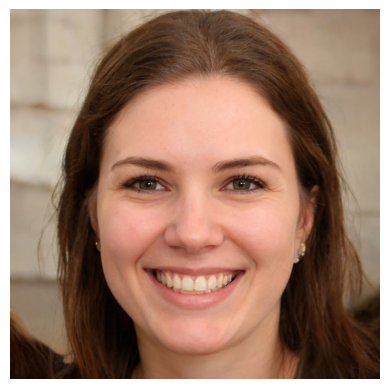

Predicted class: 0


In [ ]:
plt.imshow(img)
plt.axis('off')
plt.show()

logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", predicted_class_idx)

In [296]:
import json
import random

# Load the nombres.json file
with open('nombres.json', 'r', encoding='utf-8') as f:
    nombres_data = json.load(f)

easyMode = True
easyNames = nombres_data["nombresFacil"]
hardNames = nombres_data["nombresDificil"]

allNames = easyNames if easyMode else hardNames

In [297]:
def get_image_is_male(img):
    input = processor(images=[img], return_tensors="pt")
    outputs = model(**input)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()
    return predicted_class_idx